In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Get iris dataset

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
iris = pd.DataFrame(iris.data, columns=iris.feature_names)
iris['target'] = load_iris().target

In [10]:
iris['target'].unique()

array([0, 1, 2])

In [26]:
X = iris.drop('target', axis=1).values
y = iris['target'].values

# Work on the model

In [38]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):

        # Decision Node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node
        self.value = value

In [ ]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=2):

        self.min_samples_split = min_samples_split
        self.max_depth = max_depth

    def build_tree(self, dataset, curr_depth=0):
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        if n_samples >= self.min_samples_split and curr_depth <= self.max_depth:
            best_split = self.best_split(dataset, n_features)

            if best_split["info_gain"] > 0:
                left_node = self.build_tree(best_split["left_dataset"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], curr_depth + 1)

                return Node(best_split["feature_idx"], best_split["threshold"], best_split["info_gain"], left_node, right_node)
            
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)
    
    def best_split(self, dataset, n_features):
        best_split = {'feature_idx': None, 'threshold': None, 'info_gain': -1, 'left_dataset': None, 'right_dataset': None}

        for feature_idx in range(n_features):
            feature_values = dataset[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_dataset, right_dataset = self.split(dataset, feature_idx, threshold)

                if len(left_dataset) and len(right_dataset):
                    parent_y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]

                    info_gain = self.information_gain(parent_y, left_y, right_y)

                    if info_gain > best_split['info_gain']:
                        best_split['feature_idx'] = feature_idx
                        best_split['threshold'] = threshold
                        best_split['info_gain'] = info_gain
                        best_split['left_dataset'] = left_dataset
                        best_split['right_dataset'] = right_dataset

        return best_split
    
    def split(self, dataset, feature_idx, threshold):
        left_dataset = np.array([row for row in dataset if row[feature_idx] <= threshold])
        right_dataset = np.array([row for row in dataset if row[feature_idx] > threshold])

        return left_dataset, right_dataset
    
    def information_gain(self, parent_y, left_y, right_y):
        left_weight = len(left_y) / len(parent_y)
        right_weight = len(right_y) / len(parent_y)

        information_gain = self.entropy(parent_y) - (left_weight * self.entropy(left_y) + right_weight * self.entropy(right_y))
        return information_gain
    
    def entropy(self, y):
        entropy = 0

        class_labels = np.unique(y)
        for class_label in class_labels:
            p = len(y[y == class_label]) / len(y)
            entropy += -p * np.log2(p)
        
        return entropy
    
    def fit(self, X, y):
        dataset = np.concatenate([X, y.reshape(-1, 1)], axis=1)
        self.root = self.build_tree(dataset)
    
    def predict(self, X):
        predictions = [self.predict_class(row, self.root) for row in X]
        return predictions
    
    def predict_class(self, row, node):
        if node.value != None:
            return node.value
        
        feature_val = row[node.feature_idx]
        if feature_val <= node.threshold:
            return self.predict_class(row, node.left)
        else:
            return self.predict_class(row, node.right)
    
    def print_tree(self, node=None, feature_names=None, class_names=None, figsize=None):
        if node is None:
            node = self.root

        if node is None:
            raise ValueError("A arvore ainda nao foi treinada. Rode fit(X, y) antes de print_tree().")

        def tree_depth(current_node):
            if current_node is None or current_node.value is not None:
                return 0
            return 1 + max(tree_depth(current_node.left), tree_depth(current_node.right))

        def count_leaves(current_node):
            if current_node is None:
                return 0
            if current_node.value is not None:
                return 1
            return count_leaves(current_node.left) + count_leaves(current_node.right)

        def node_text(current_node):
            if current_node.value is not None:
                class_label = current_node.value
                if class_names is not None:
                    class_label = class_names[int(current_node.value)]
                return f"Classe: {class_label}"

            feature_label = f"Feature {current_node.feature_idx}"
            if feature_names is not None:
                feature_label = feature_names[current_node.feature_idx]
            return f"{feature_label}\n<= {current_node.threshold:.3f}\ngain = {current_node.info_gain:.3f}"

        max_depth = tree_depth(node)
        total_leaves = max(count_leaves(node), 1)
        if figsize is None:
            figsize = (max(8, total_leaves * 2.2), max(5, (max_depth + 1) * 1.6))

        fig, ax = plt.subplots(figsize=figsize)
        ax.axis("off")
        leaf_x = 0

        def draw_node(current_node, depth=0):
            nonlocal leaf_x

            y = -depth
            if current_node.value is not None:
                x = leaf_x
                leaf_x += 1
            else:
                left_x, left_y = draw_node(current_node.left, depth + 1)
                right_x, right_y = draw_node(current_node.right, depth + 1)
                x = (left_x + right_x) / 2

                ax.annotate("sim", xy=(left_x, left_y), xytext=(x, y),
                            ha="center", va="center", fontsize=9,
                            arrowprops=dict(arrowstyle="->", lw=1.2, color="#555555FF"))
                ax.annotate("nao", xy=(right_x, right_y), xytext=(x, y),
                            ha="center", va="center", fontsize=9,
                            arrowprops=dict(arrowstyle="->", lw=1.2, color="#555555"))

            box_color = "#d8f3dc" if current_node.value is not None else "#dbeafe"
            ax.text(x, y, node_text(current_node), ha="center", va="center", fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.45", facecolor=box_color,
                              edgecolor="#334155", linewidth=1.2))
            return x, y

        draw_node(node)
        ax.set_xlim(-0.8, max(total_leaves - 0.2, 1))
        ax.set_ylim(-(max_depth + 0.8), 0.8)
        plt.tight_layout()
        plt.show()
        return fig, ax

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [40]:
dt = DecisionTree(min_samples_split=2, max_depth=2)
dt.fit(X_train, y_train)
predictions = dt.predict(X_test)

accuracy = np.mean(predictions == y_test) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 96.67%


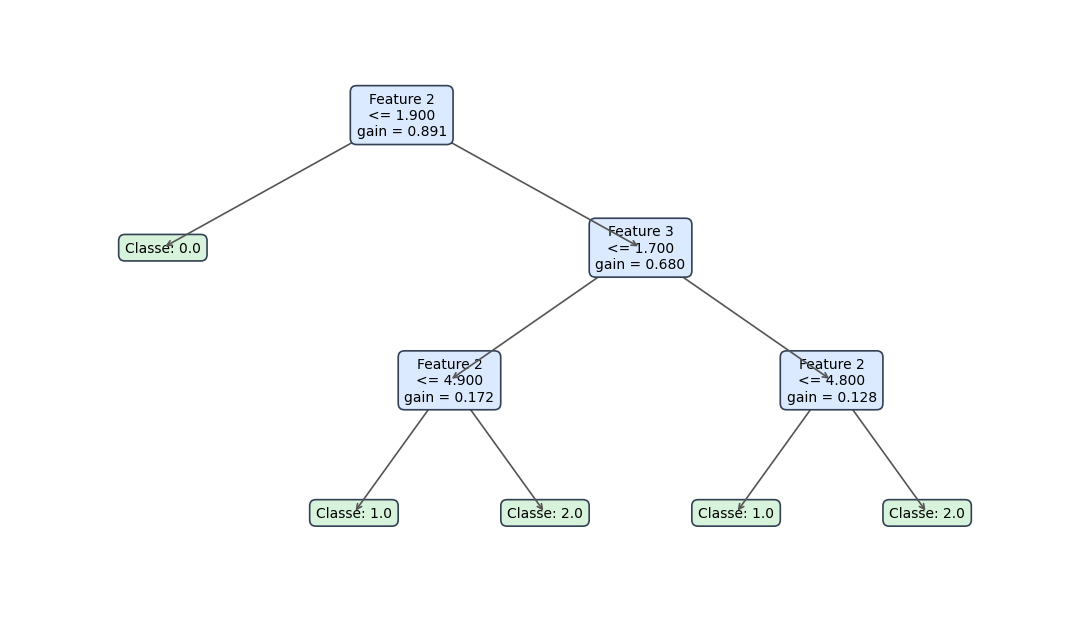

(<Figure size 1100x640 with 1 Axes>, <Axes: >)

In [41]:
dt.print_tree()
